### Why PCA?

Our EDA and feature engineering created several highly correlated features: `Mental Fatigue Score`, `Stress Index`, `Workload Fatigue Interaction`, and `Fatigue Ratio` all capture overlapping information. PCA addresses this by:
1. **Removing multicollinearity** — each principal component is orthogonal by definition
2. **Compressing variance** — we can retain 95%+ of information with fewer dimensions
3. **Revealing structure** — the loading matrix shows which original features each component represents

### Why Gradient Boosting?

Gradient Boosting builds trees sequentially, each correcting the residual errors of the previous one. Compared to Random Forest (which averages parallel trees), GBM often achieves lower bias on structured tabular data and is more sensitive to subtle nonlinear patterns making it a strong complement to the RF baseline already established by the team.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# data
train = pd.read_csv('train.csv')
print(f"Raw training set shape: {train.shape}")
train.head(3)

Raw training set shape: (22750, 9)


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49


In [3]:

df = train.copy()

# Drop nonpredictive ID
df = df.drop(columns=["Employee ID"])

# Drop rows where target (Burn Rate) is missing
df = df.dropna(subset=["Burn Rate"]).copy()

# Date of Joining days_since_joined 
df["Date of Joining"] = pd.to_datetime(df["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df["days_since_joined"] = (reference_date - df["Date of Joining"]).dt.days
df = df.drop(columns=["Date of Joining"])

# Binary encoding for categorical columns
df["gender"]       = df["Gender"].map({"Male": 1, "Female": 0})
df["company_type"] = df["Company Type"].map({"Service": 1, "Product": 0})
df["is_wfh"]       = df["WFH Setup Available"].map({"Yes": 1, "No": 0})
df = df.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

# Probabilistic imputation (MCAR-confirmed via permutation tests)
rng = np.random.default_rng(RANDOM_STATE)
for col in ["Mental Fatigue Score", "Resource Allocation"]:
    missing_mask = df[col].isna()
    observed_vals = df.loc[~missing_mask, col].values
    df.loc[missing_mask, col] = rng.choice(observed_vals, size=missing_mask.sum(), replace=True)

# Feature engineering 
df["Workload Fatigue Interaction"] = df["Resource Allocation"] * df["Mental Fatigue Score"]
df["Fatigue Ratio"]  = df["Mental Fatigue Score"] / df["Resource Allocation"]
df["High Workload"]  = (df["Resource Allocation"] > df["Resource Allocation"].median()).astype(int)
df["High Fatigue"]   = (df["Mental Fatigue Score"] > df["Mental Fatigue Score"].median()).astype(int)
df["Stress Index"]   = 0.7 * df["Mental Fatigue Score"] + 0.3 * df["Resource Allocation"]

print(f"Processed dataset shape: {df.shape}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"\nFeatures: {[c for c in df.columns if c != 'Burn Rate']}")

Processed dataset shape: (21626, 13)
Missing values remaining: 0

Features: ['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'days_since_joined', 'gender', 'company_type', 'is_wfh', 'Workload Fatigue Interaction', 'Fatigue Ratio', 'High Workload', 'High Fatigue', 'Stress Index']


## Feature Correlation Heatmap

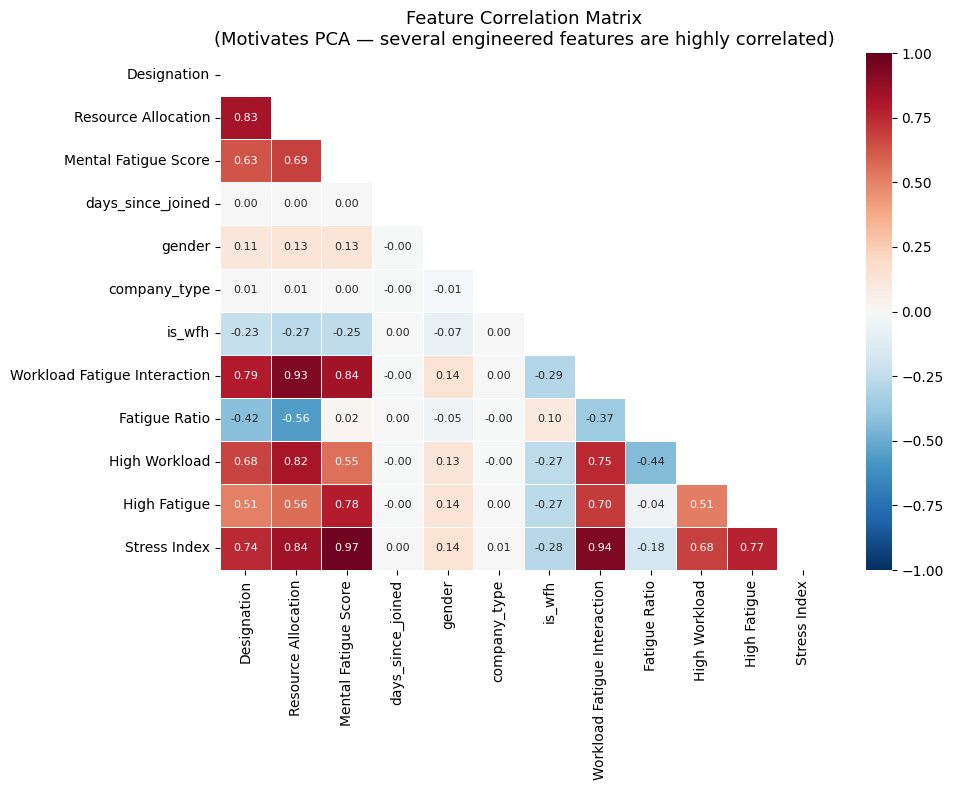

Highly correlated feature pairs (|r| > 0.80):
  Mental Fatigue Score                <-> Stress Index                         r = 0.970
  Workload Fatigue Interaction        <-> Stress Index                         r = 0.935
  Resource Allocation                 <-> Workload Fatigue Interaction         r = 0.930
  Resource Allocation                 <-> Stress Index                         r = 0.844
  Mental Fatigue Score                <-> Workload Fatigue Interaction         r = 0.843
  Designation                         <-> Resource Allocation                  r = 0.831
  Resource Allocation                 <-> High Workload                        r = 0.823


In [4]:
feature_cols = [c for c in df.columns if c != "Burn Rate"]

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Feature Correlation Matrix\n(Motivates PCA — several engineered features are highly correlated)", fontsize=13)
plt.tight_layout()
plt.show()

# Identify highly correlated pairs 
high_corr = [
    (c1, c2, corr.loc[c1, c2])
    for i, c1 in enumerate(feature_cols)
    for c2 in feature_cols[i+1:]
    if abs(corr.loc[c1, c2]) > 0.80
]
print("Highly correlated feature pairs (|r| > 0.80):")
for c1, c2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f"  {c1:35s} <-> {c2:35s}  r = {r:.3f}")

## Standardize features 

In [5]:
X = df[feature_cols].values
y = df["Burn Rate"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Mean ≈ 0 after scaling: {X_scaled.mean(axis=0).round(10)}")

Feature matrix shape: (21626, 12)
Mean ≈ 0 after scaling: [ 0. -0.  0. -0.  0. -0.  0.  0. -0.  0. -0.  0.]


## PCA Explained Variance Analysis 

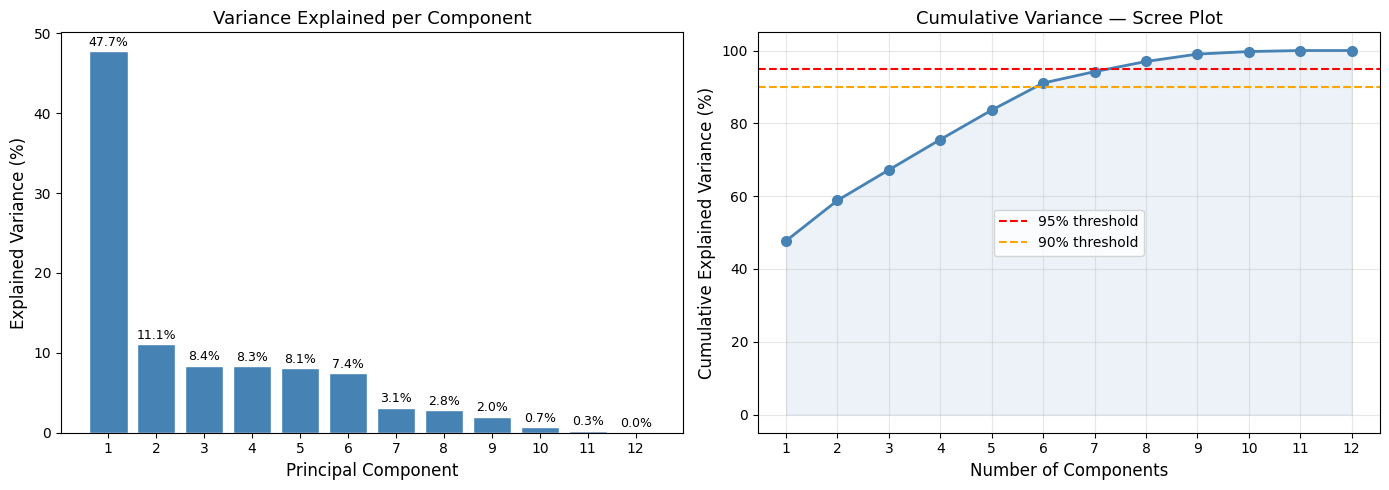

Components needed to reach variance threshold:
  90% variance → 6 components
  95% variance → 8 components
  99% variance → 9 components


In [6]:
# Full PCA to assess variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: individual explained variance per component
axes[0].bar(range(1, len(evr)+1), evr * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Principal Component", fontsize=12)
axes[0].set_ylabel("Explained Variance (%)", fontsize=12)
axes[0].set_title("Variance Explained per Component", fontsize=13)
axes[0].set_xticks(range(1, len(evr)+1))
for i, v in enumerate(evr):
    axes[0].text(i+1, v*100 + 0.3, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=9)

# Right: cumulative explained variance (scree plot)
axes[1].plot(range(1, len(cumulative_evr)+1), cumulative_evr * 100,
             marker='o', color='steelblue', linewidth=2, markersize=7)
axes[1].axhline(95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].axhline(90, color='orange', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].fill_between(range(1, len(cumulative_evr)+1), cumulative_evr * 100, alpha=0.1, color='steelblue')
axes[1].set_xlabel("Number of Components", fontsize=12)
axes[1].set_ylabel("Cumulative Explained Variance (%)", fontsize=12)
axes[1].set_title("Cumulative Variance — Scree Plot", fontsize=13)
axes[1].set_xticks(range(1, len(cumulative_evr)+1))
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Components needed to reach variance threshold:")
for threshold in [0.90, 0.95, 0.99]:
    n = np.argmax(cumulative_evr >= threshold) + 1
    print(f"  {threshold*100:.0f}% variance → {n} components")

## PCA Component Loading Analysis

Components retained (95% variance): 8 out of 12
Total variance explained: 96.99%


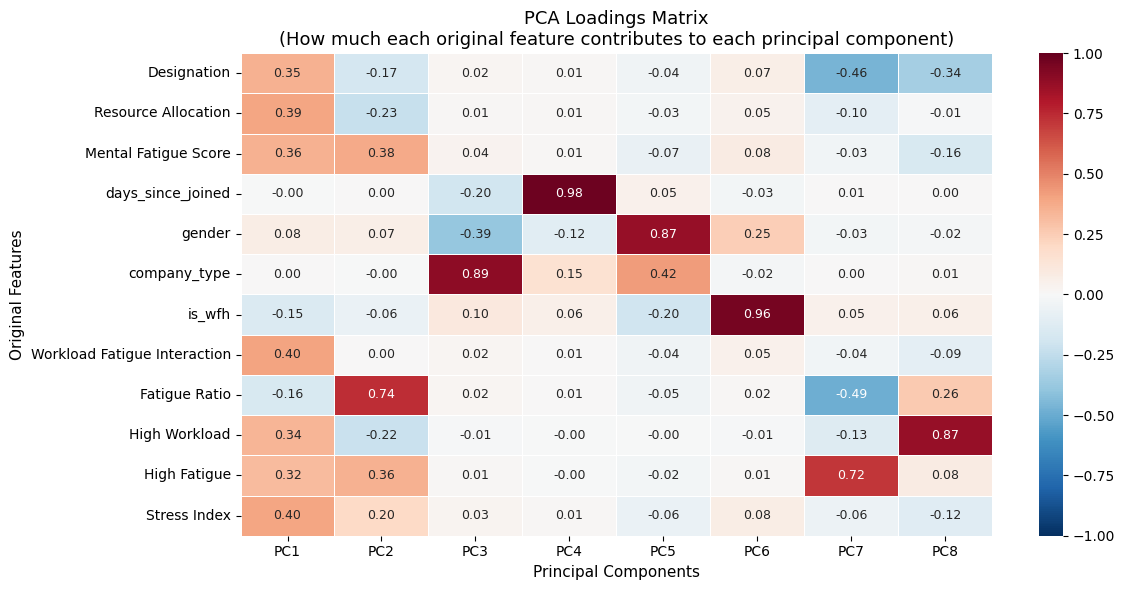


Top 3 features by absolute loading per component:
  PC1: Workload Fatigue Interaction (+0.40), Stress Index (+0.40), Resource Allocation (+0.39)
  PC2: Fatigue Ratio (+0.74), Mental Fatigue Score (+0.38), High Fatigue (+0.36)
  PC3: company_type (+0.89), gender (-0.39), days_since_joined (-0.20)
  PC4: days_since_joined (+0.98), company_type (+0.15), gender (-0.12)
  PC5: gender (+0.87), company_type (+0.42), is_wfh (-0.20)
  PC6: is_wfh (+0.96), gender (+0.25), Mental Fatigue Score (+0.08)
  PC7: High Fatigue (+0.72), Fatigue Ratio (-0.49), Designation (-0.46)
  PC8: High Workload (+0.87), Designation (-0.34), Fatigue Ratio (+0.26)


In [7]:
# Fit PCA retaining 95% of variance
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

n_components = pca.n_components_
print(f"Components retained (95% variance): {n_components} out of {X_scaled.shape[1]}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Loadings heatmap 
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    loadings, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={"size": 9}, ax=ax
)
ax.set_title("PCA Loadings Matrix\n(How much each original feature contributes to each principal component)", fontsize=13)
ax.set_xlabel("Principal Components", fontsize=11)
ax.set_ylabel("Original Features", fontsize=11)
plt.tight_layout()
plt.show()

# Dominant features per component
print("\nTop 3 features by absolute loading per component:")
for pc in loadings.columns:
    top = loadings[pc].abs().nlargest(3)
    print(f"  {pc}: {', '.join([f'{f} ({loadings[pc][f]:+.2f})' for f in top.index])}")

## Train Split 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Features     : {X_train.shape[1]} principal components")

Training set : 17,300 samples
Test set     : 4,326 samples
Features     : 8 principal components


## Gradient Boosting Model 

In [9]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

gb_model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## Hold out test

In [10]:
y_pred = gb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("PCA + Gradient Boosting — Test Set Results")
print("=" * 45)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

print("\nComparison to team baselines:")
print(f"{'Model':<35} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("-" * 58)
print(f"{'Random Forest (team baseline)':<35} {'0.0631':>7} {'0.0492':>7} {'0.8953':>7}")
print(f"{'PCA + Gradient Boosting (this notebook)':<35} {rmse:>7.4f} {mae:>7.4f} {r2:>7.4f}")

PCA + Gradient Boosting — Test Set Results
RMSE : 0.0692
MAE  : 0.0523
R²   : 0.8741

Comparison to team baselines:
Model                                  RMSE     MAE      R²
----------------------------------------------------------
Random Forest (team baseline)        0.0631  0.0492  0.8953
PCA + Gradient Boosting (this notebook)  0.0692  0.0523  0.8741


## 5 fold cross Validation

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rmse = np.sqrt(-cross_val_score(
    gb_model, X_pca, y,
    cv=kf, scoring='neg_mean_squared_error', n_jobs=-1
))
cv_r2 = cross_val_score(
    gb_model, X_pca, y,
    cv=kf, scoring='r2', n_jobs=-1
)

print("5-Fold Cross-Validation Results — PCA + Gradient Boosting")
print("=" * 55)
print(f"RMSE per fold : {[round(v, 4) for v in cv_rmse]}")
print(f"RMSE mean ± std: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"R²   per fold : {[round(v, 4) for v in cv_r2]}")
print(f"R²   mean ± std: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

5-Fold Cross-Validation Results — PCA + Gradient Boosting
RMSE per fold : [np.float64(0.0695), np.float64(0.0715), np.float64(0.0704), np.float64(0.072), np.float64(0.0712)]
RMSE mean ± std: 0.0709 ± 0.0009
R²   per fold : [np.float64(0.8733), np.float64(0.8714), np.float64(0.8749), np.float64(0.8698), np.float64(0.8706)]
R²   mean ± std: 0.8720 ± 0.0019


## Residual Analysis

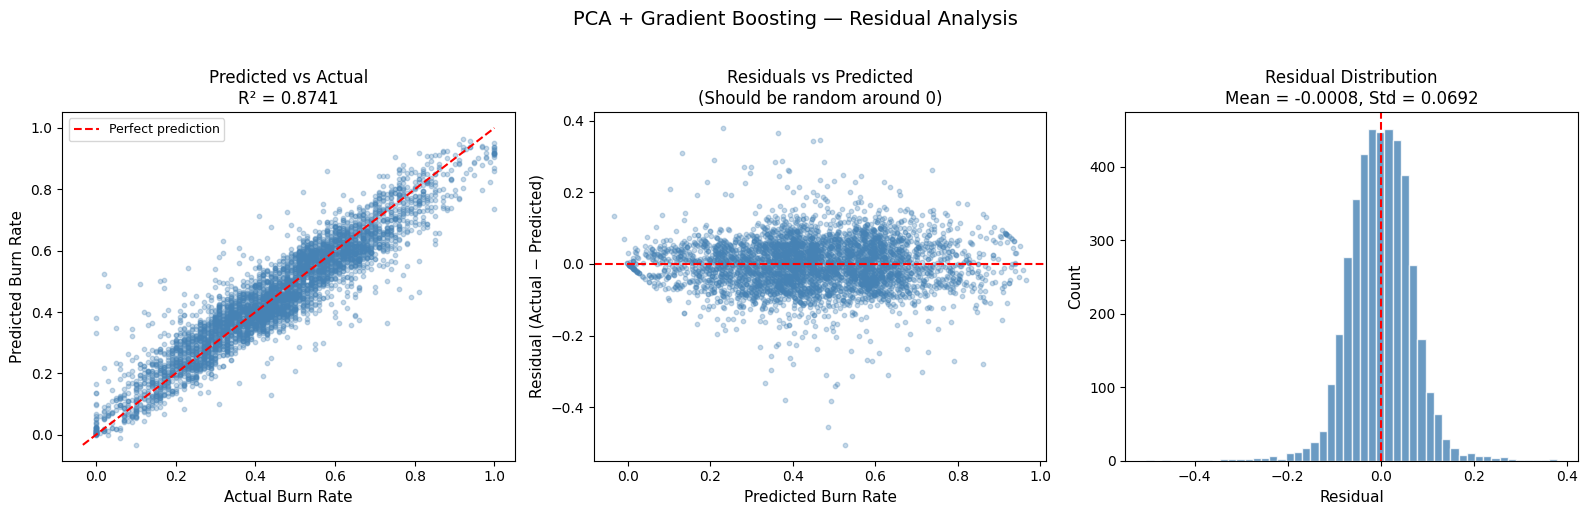

In [12]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel("Actual Burn Rate", fontsize=11)
axes[0].set_ylabel("Predicted Burn Rate", fontsize=11)
axes[0].set_title(f"Predicted vs Actual\nR² = {r2:.4f}", fontsize=12)
axes[0].legend(fontsize=9)

# Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Predicted Burn Rate", fontsize=11)
axes[1].set_ylabel("Residual (Actual − Predicted)", fontsize=11)
axes[1].set_title("Residuals vs Predicted\n(Should be random around 0)", fontsize=12)

# Residual distribution
axes[2].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel("Residual", fontsize=11)
axes[2].set_ylabel("Count", fontsize=11)
axes[2].set_title(f"Residual Distribution\nMean = {residuals.mean():.4f}, Std = {residuals.std():.4f}", fontsize=12)

plt.suptitle("PCA + Gradient Boosting — Residual Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Feature Importance via PCA Component Contributions

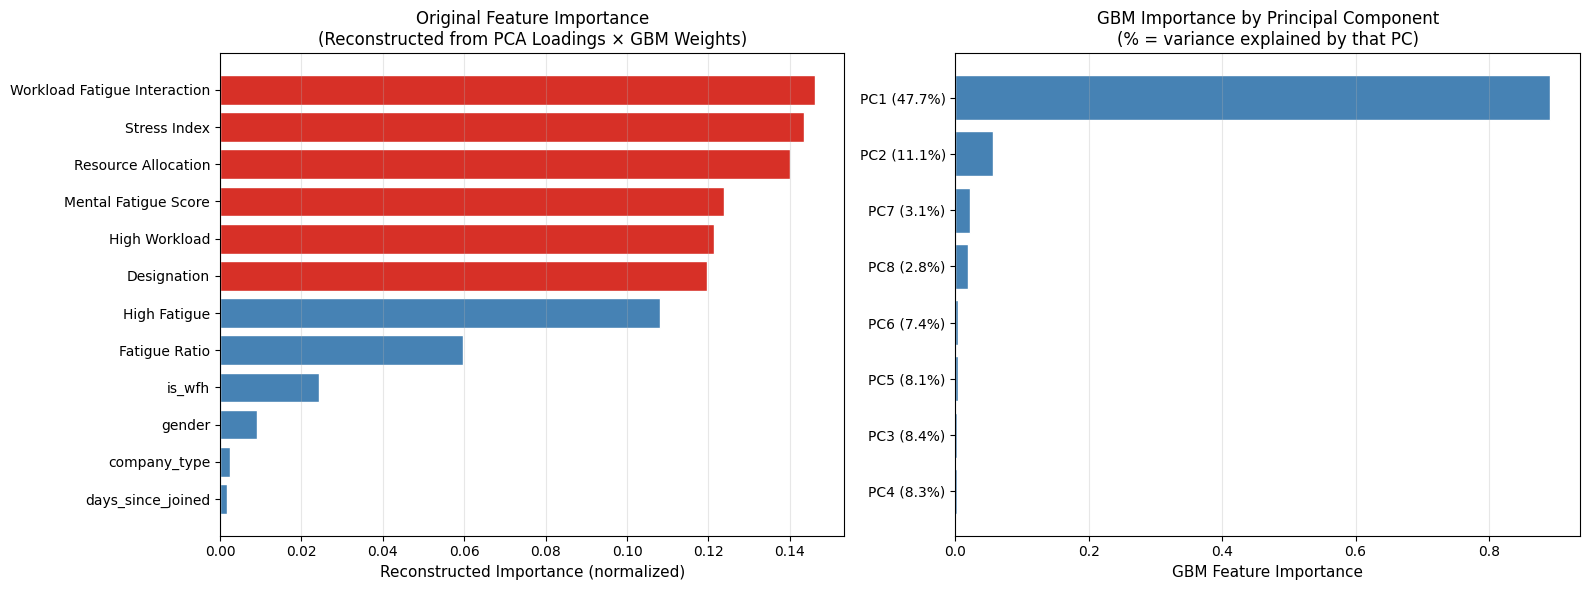


Original Feature Importances (Reconstructed):
                     Feature  Reconstructed Importance
Workload Fatigue Interaction                  0.146105
                Stress Index                  0.143449
         Resource Allocation                  0.140069
        Mental Fatigue Score                  0.123899
               High Workload                  0.121239
                 Designation                  0.119681
                High Fatigue                  0.108193
               Fatigue Ratio                  0.059781
                      is_wfh                  0.024297
                      gender                  0.009072
                company_type                  0.002503
           days_since_joined                  0.001713


In [13]:
# GBM feature importances (on PCA components)
gb_importances = gb_model.feature_importances_  # shape: (n_components,)

# Reconstruct original feature importance:
# For each original feature, sum: loading² × component_importance across all PCs
# (squared loading = proportion of original feature variance in that PC)
loadings_matrix = np.abs(pca.components_.T)  # shape: (n_features, n_components)
orig_importance = (loadings_matrix ** 2 * gb_importances).sum(axis=1)
orig_importance = orig_importance / orig_importance.sum()  # normalize

# Sorting for plotting
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Reconstructed Importance': orig_importance
}).sort_values('Reconstructed Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: reconstructed original feature importances
colors = ['#d73027' if v > importance_df['Reconstructed Importance'].median() else 'steelblue'
          for v in importance_df['Reconstructed Importance']]
axes[0].barh(importance_df['Feature'], importance_df['Reconstructed Importance'],
             color=colors, edgecolor='white')
axes[0].set_xlabel("Reconstructed Importance (normalized)", fontsize=11)
axes[0].set_title("Original Feature Importance\n(Reconstructed from PCA Loadings × GBM Weights)", fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Right: GBM importance on PCA components directly
pc_labels = [f"PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)" for i in range(n_components)]
pc_imp_df = pd.DataFrame({'PC': pc_labels, 'GBM Importance': gb_importances}).sort_values('GBM Importance', ascending=True)
axes[1].barh(pc_imp_df['PC'], pc_imp_df['GBM Importance'], color='steelblue', edgecolor='white')
axes[1].set_xlabel("GBM Feature Importance", fontsize=11)
axes[1].set_title("GBM Importance by Principal Component\n(% = variance explained by that PC)", fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nOriginal Feature Importances (Reconstructed):")
print(importance_df.sort_values('Reconstructed Importance', ascending=False).to_string(index=False))